In [2]:
import pandas as pd 
sales_long = pd.read_csv('C:/Users/shrut/Desktop/walmart/walmart_m5_melted_data.csv')


In [3]:
calender= pd.read_csv('C:/Users/shrut/Desktop/walmart/clean_calender.csv')


In [4]:
calender.head(1)

,date,d,wday,is_holiday,wm_yr_wk,snap_CA,snap_TX,snap_WI,is_weekend
0,2011-01-29,d_1,1,0,11101,0,0,0,1


In [5]:
sales_long.head(1)

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales
0,14370,1437,3,1,0,0,d_1,0


In [6]:
sales_long = sales_long.merge(
    calender[['d', 'is_holiday', 'is_weekend']],
    left_on='day',
    right_on='d',
    how='left',
).drop(columns=['d'])

In [7]:
sales_long.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,is_holiday,is_weekend
0,14370,1437,3,1,0,0,d_1,0,0,1
1,14370,1437,3,1,0,0,d_2,0,0,1
2,14370,1437,3,1,0,0,d_3,0,0,0
3,14370,1437,3,1,0,0,d_4,0,0,0
4,14370,1437,3,1,0,0,d_5,0,0,0


In [10]:
# Step 1: Sum sales for each department on each day
daily_dept_sales = (
    sales_long.groupby(['dept_id', 'day', 'is_holiday'])['sales']
    .sum()
    .reset_index()
)

# Step 2: Calculate average total daily department sales for Holiday vs Non-Holiday
total_dept_holiday = (
    daily_dept_sales.groupby(['dept_id', 'is_holiday'])['sales']
    .mean()
    .unstack()
)

# Calculate Lift and Percentage Change
total_dept_holiday['daily_unit_lift'] = (
    total_dept_holiday[1] - total_dept_holiday[0]
)
total_dept_holiday['pct_change'] = (
    total_dept_holiday['daily_unit_lift'] / total_dept_holiday[0]
) * 100

print(
    total_dept_holiday.rename(
        columns={
            0: 'Avg_Total_Units_Non_Holiday',
            1: 'Avg_Total_Units_Holiday',
        }
    )
)

is_holiday  Avg_Total_Units_Non_Holiday  Avg_Total_Units_Holiday  \
dept_id                                                            
0                           2668.817510              2555.785714   
1                           4012.289369              3715.616883   
2                          16963.923820             16445.025974   
3                           2948.237067              2665.655844   
4                            278.447413               250.331169   
5                           6051.738488              5555.311688   
6                           1565.753837              1467.422078   

is_holiday  daily_unit_lift  pct_change  
dept_id                                  
0               -113.031796   -4.235276  
1               -296.672486   -7.394095  
2               -518.897846   -3.058832  
3               -282.581222   -9.584752  
4                -28.116244  -10.097506  
5               -496.426799   -8.203044  
6                -98.331759   -6.280154  


In [11]:
# Step 1: Sum sales for each department on each day
daily_dept_sales_weekend = (
    sales_long.groupby(['dept_id', 'day', 'is_weekend'])['sales']
    .sum()
    .reset_index()
)

# Step 2: Calculate average total daily department sales for Weekday vs Weekend
total_dept_weekend = (
    daily_dept_sales_weekend.groupby(['dept_id', 'is_weekend'])['sales']
    .mean()
    .unstack()
)

# Calculate Lift and Percentage Change
total_dept_weekend['daily_unit_lift'] = (
    total_dept_weekend[1] - total_dept_weekend[0]
)
total_dept_weekend['pct_change'] = (
    total_dept_weekend['daily_unit_lift'] / total_dept_weekend[0]
) * 100

print(
    total_dept_weekend.rename(
        columns={
            0: 'Avg_Total_Units_Weekday',
            1: 'Avg_Total_Units_Weekend',
        }
    )
)

is_weekend  Avg_Total_Units_Weekday  Avg_Total_Units_Weekend  daily_unit_lift  \
dept_id                                                                         
0                       2500.135531              3057.218978       557.083447   
1                       3711.635897              4677.808394       966.172497   
2                      15494.996337             20477.018248      4982.021911   
3                       2718.273260              3441.636861       723.363601   
4                        264.366300               305.620438        41.254138   
5                       5434.992674              7448.468978      2013.476304   
6                       1408.152381              1930.686131       522.533750   

is_weekend  pct_change  
dept_id                 
0            22.282130  
1            26.030907  
2            32.152456  
3            26.611144  
4            15.604915  
5            37.046532  
6            37.107756  


In [13]:
# 1. Dept aur Day level par Total Daily Sales nikal lo
daily_sales = (
    sales_long.groupby(['dept_id', 'day', 'is_holiday'])['sales']
    .sum()
    .reset_index()
)

# 2. Key Step: is_holiday ko 1 din peeche shift karo (meaning: kal holiday hai ya nahi)
# Shift karne se 'is_holiday_tomorrow' column ban jayega bina kisi merge ke
daily_sales['is_holiday_tomorrow'] = daily_sales['is_holiday'].shift(-1)

# 3. Normal Day vs 1 Day Before Holiday ka average compare kar lo
pre_holiday = (
    daily_sales.groupby(['dept_id', 'is_holiday_tomorrow'])['sales']
    .mean()
    .unstack()
)

# Lift & Percentage Change
pre_holiday['lift'] = pre_holiday[1] - pre_holiday[0]
pre_holiday['pct_change'] = (pre_holiday['lift'] / pre_holiday[0]) * 100

print(
    pre_holiday.rename(
        columns={
            0: 'Avg_Normal_Day_Sales',
            1: 'Avg_1_Day_Before_Holiday_Sales',
        }
    )
)

is_holiday_tomorrow  Avg_Normal_Day_Sales  Avg_1_Day_Before_Holiday_Sales  \
dept_id                                                                     
0                             2634.881751                     2943.402597   
1                             3973.801592                     4155.227273   
2                            16798.255259                    18337.305195   
3                             2911.385446                     3086.577922   
4                              275.216032                      287.240260   
5                             5983.270040                     6337.363636   
6                             1549.215017                     1658.714286   

is_holiday_tomorrow         lift  pct_change  
dept_id                                       
0                     308.520846   11.709096  
1                     181.425681    4.565545  
2                    1539.049936    9.161963  
3                     175.192476    6.017495  
4                      1

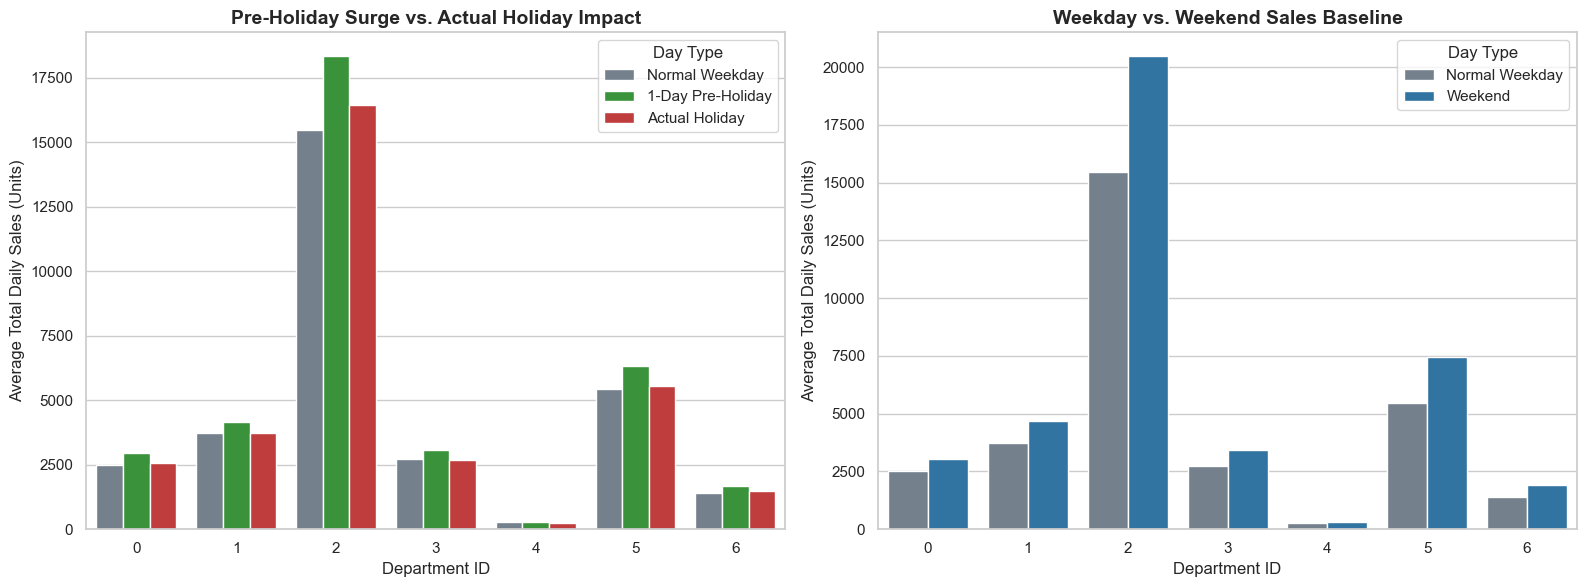

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# 1. Prepare Daily Sales & Indicators without extra merges
daily_sales = (
    sales_long.groupby(['dept_id', 'day', 'is_holiday', 'is_weekend'])['sales']
    .sum()
    .reset_index()
)

# Create 1-day pre-holiday indicator using shift
daily_sales['is_pre_holiday'] = daily_sales['is_holiday'].shift(-1).fillna(0)

# 2. Calculate Averages by Department
# Normal Day: Not holiday, Not pre-holiday, Not weekend
normal_days = (
    daily_sales[
        (daily_sales['is_holiday'] == 0)
        & (daily_sales['is_pre_holiday'] == 0)
        & (daily_sales['is_weekend'] == 0)
    ]
    .groupby('dept_id')['sales']
    .mean()
)

pre_holiday_days = (
    daily_sales[daily_sales['is_pre_holiday'] == 1]
    .groupby('dept_id')['sales']
    .mean()
)
weekend_days = (
    daily_sales[daily_sales['is_weekend'] == 1]
    .groupby('dept_id')['sales']
    .mean()
)
holiday_days = (
    daily_sales[daily_sales['is_holiday'] == 1]
    .groupby('dept_id')['sales']
    .mean()
)

# Combine into a single plotting DataFrame
plot_df = pd.DataFrame(
    {
        'Normal Weekday': normal_days,
        '1-Day Pre-Holiday': pre_holiday_days,
        'Actual Holiday': holiday_days,
        'Weekend': weekend_days,
    }
).reset_index()

# Melt dataframe for Seaborn barplot
plot_melted = pd.melt(
    plot_df,
    id_vars=['dept_id'],
    var_name='Day_Type',
    value_name='Avg_Total_Daily_Sales',
)

# 3. Create Side-by-Side Plots for Report
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Pre-Holiday vs Actual Holiday vs Normal Weekday
sns.barplot(
    data=plot_melted[
        plot_melted['Day_Type'].isin(
            ['Normal Weekday', '1-Day Pre-Holiday', 'Actual Holiday']
        )
    ],
    x='dept_id',
    y='Avg_Total_Daily_Sales',
    hue='Day_Type',
    palette=['#708090', '#2ca02c', '#d62728'],
    ax=axes[0],
)
axes[0].set_title(
    'Pre-Holiday Surge vs. Actual Holiday Impact',
    fontsize=14,
    fontweight='bold',
)
axes[0].set_xlabel('Department ID')
axes[0].set_ylabel('Average Total Daily Sales (Units)')
axes[0].legend(title='Day Type')

# Plot 2: Weekday vs Weekend Comparison
sns.barplot(
    data=plot_melted[
        plot_melted['Day_Type'].isin(['Normal Weekday', 'Weekend'])
    ],
    x='dept_id',
    y='Avg_Total_Daily_Sales',
    hue='Day_Type',
    palette=['#708090', '#1f77b4'],
    ax=axes[1],
)
axes[1].set_title(
    'Weekday vs. Weekend Sales Baseline', fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Department ID')
axes[1].set_ylabel('Average Total Daily Sales (Units)')
axes[1].legend(title='Day Type')

plt.tight_layout()
plt.savefig('holiday_weekend_impact_report.png', dpi=300)
plt.show()